# Problem 5.2: Deep Convolutional GAN (DCGAN)

## Overview

In this notebook we build a **Deep Convolutional Generative Adversarial Network (DCGAN)** trained on the **CIFAR-10** dataset.

A GAN consists of two neural networks trained in an adversarial game:

| Component | Role | Goal |
|-----------|------|------|
| **Generator** | Takes random noise *z* ~ N(0,1) and produces a synthetic image | Fool the discriminator |
| **Discriminator** | Takes an image (real or fake) and outputs P(real) | Correctly distinguish real from fake |

### Steps in this notebook
1. Load CIFAR-10 and rescale pixel values to [−1, 1]
2. Implement Generator (ConvTranspose2d blocks, Tanh output)
3. Implement Discriminator (Conv2d blocks, Sigmoid output)
4. Adversarial training loop with separate Adam optimisers
5. Monitor quality via FID score and loss curves
6. Visualise synthetic images throughout training
7. Discuss challenges and solutions applied

## 1. Imports & Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchmetrics
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


## 2. Data Loading – CIFAR-10

CIFAR-10 contains 60 000 colour images (32×32 px, 3 channels) across 10 classes.
Each channel is normalised with mean=0.5 and std=0.5, mapping pixel values to **[−1, 1]**.
This matches the **Tanh** output range of the generator.

> For training we used GPU on home PC, restarting the cells on CPU setup could take long time.

Training samples : 50000
Batches per epoch: 390


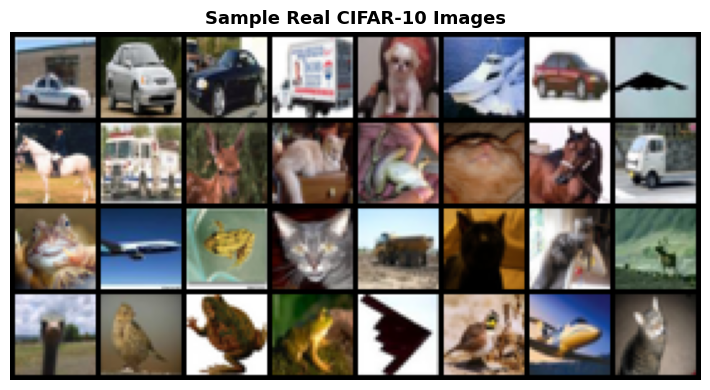

In [2]:
BATCH_SIZE = 128
LATENT_DIM = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform #once the dataset is downloaded, parameter download=False should work
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, drop_last=True
)

print(f'Training samples : {len(train_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')

# Show a grid of real samples (de-normalised for display)
real_batch, _ = next(iter(train_loader))
grid = torchvision.utils.make_grid(real_batch[:32] * 0.5 + 0.5, nrow=8, padding=2)
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title('Sample Real CIFAR-10 Images', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Model Architecture

### 3.1 Weight Initialisation

All convolutional and transposed-convolutional weights are sampled from **N(0, 0.02)**.
BatchNorm scale and bias are initialised to **N(1.0, 0.02)** and **0**, respectively.

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### 3.2 Generator

The generator up-samples a 100-dimensional noise vector into a 3×32×32 image
via a series of transposed convolutions:

```
100×1×1  →  512×4×4  →  256×8×8  →  128×16×16  →  3×32×32
```

Each intermediate block: `ConvTranspose2d → BatchNorm2d → ReLU`  
Final layer: no BatchNorm, activation = **Tanh** (outputs values in [−1, 1])

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            # 100x1x1 -> 512x4x4
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False), #convolutions are used to upsample the input noise vector into an image
            nn.BatchNorm2d(512), #Batch normalization is applied to stabilize training and improve convergence by normalizing the activations of the previous layer
            nn.ReLU(True), 
            # 512x4x4 -> 256x8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256x8x8 -> 128x16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128x16x16 -> 3x32x32  (no BatchNorm, Tanh)
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

### 3.3 Discriminator

The discriminator down-samples a 3×32×32 image to a single probability scalar
via strided convolutions:

```
3×32×32  →  128×16×16  →  256×8×8  →  512×4×4  →  1×1×1
```

Each intermediate block: `Conv2d → BatchNorm2d → LeakyReLU(0.2)`  
**First and last layers** omit BatchNorm. Final activation = **Sigmoid**.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 3x32x32 -> 128x16x16  (first layer: no BatchNorm)
            nn.Conv2d(3, 128, 4, 2, 1, bias=False), #convolutions are used to downsample the input image into a single scalar output representing the probability of the input being real or fake
            nn.LeakyReLU(0.2, inplace=True), #LeakyReLU is used as the activation function to allow a small gradient when the unit is not active, which helps prevent the "dying ReLU" problem and allows for better gradient flow during training
            # 128x16x16 -> 256x8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256x8x8 -> 512x4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 512x4x4 -> 1x1x1  (last layer: no BatchNorm, Sigmoid)
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1)

### 3.4 Model Instantiation

In [6]:
netG = Generator(LATENT_DIM).to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

n_G = sum(p.numel() for p in netG.parameters())
n_D = sum(p.numel() for p in netD.parameters())
print(f'Generator     parameters: {n_G:,}')
print(f'Discriminator parameters: {n_D:,}')
print()
print(netG)
print()
print(netD)

Generator     parameters: 3,448,576
Discriminator parameters: 2,637,312

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(n

## 4. Training Setup

| Hyperparameter | Value |
|----------------|-------|
| Loss | BCELoss |
| Optimiser | Adam, lr=0.0002 |
| β₁ | 0.5 | 
| β₂ | 0.999 |
| Latent dim | 100 |
| Batch size | 128 |}

### Binary Cross-Entropy Loss

For a single sample, BCELoss is defined as:

$$\mathcal{L}_{\text{BCE}}(y,\,\hat{y}) = -\bigl[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\bigr]$$

where $y \in \{0,1\}$ is the true label and $\hat{y} = D(x) \in (0,1)$ is the discriminator's predicted probability. Averaged over a batch of size $N$:

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_{i=1}^{N}\bigl[y_i\log D(x_i) + (1-y_i)\log(1-D(x_i))\bigr]$$

In the GAN setting this yields two objectives:

$$\mathcal{L}_D = -\mathbb{E}_{x\sim p_{\text{data}}}\!\left[\log D(x)\right] - \mathbb{E}_{z\sim p_z}\!\left[\log\bigl(1-D(G(z))\bigr)\right]$$

$$\mathcal{L}_G = -\mathbb{E}_{z\sim p_z}\!\left[\log D(G(z))\right]$$

The discriminator minimises $\mathcal{L}_D$ (correctly classifying real as 1 and fake as 0), while the generator minimises $\mathcal{L}_G$ (fooling the discriminator into outputting 1 for fake images).

Two **separate optimisers** are required because the generator and discriminator have opposing
objectives — they must never update each other's weights simultaneously.

A batch of **64 fixed noise vectors** is created once before training and reused every epoch
to track the generator's improvement on a consistent set of inputs.

In [7]:
criterion  = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 64 fixed noise vectors for visual monitoring throughout training
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
print(f'Fixed noise shape: {fixed_noise.shape}')

Fixed noise shape: torch.Size([64, 100, 1, 1])


### Helper Functions

In [8]:
def denormalize(t):
    # Convert tensors from [-1, 1] to [0, 1] for display / FID
    return (t + 1.0) / 2.0


def compute_fid(generator, real_loader, dev, n_samples=2048, latent_dim=100):
    # Returns NaN if torchmetrics is not installed
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
    except ImportError:
        return float('nan')

    fid_metric = FrechetInceptionDistance(feature=2048).to(dev)
    fid_metric.reset()

    real_count = 0
    for imgs, _ in real_loader:
        if real_count >= n_samples:
            break
        imgs_u8 = (denormalize(imgs) * 255).clamp(0, 255).to(torch.uint8).to(dev)
        fid_metric.update(imgs_u8, real=True)
        real_count += imgs.shape[0]

    generator.eval()
    fake_count = 0
    with torch.no_grad():
        while fake_count < n_samples:
            bs = min(128, n_samples - fake_count)
            z = torch.randn(bs, latent_dim, 1, 1, device=dev)
            fake_u8 = (denormalize(generator(z)) * 255).clamp(0, 255).to(torch.uint8)
            fid_metric.update(fake_u8, real=False)
            fake_count += bs
    generator.train()

    return fid_metric.compute().item()

## 5. Adversarial Training Loop

Each training step has **two phases**:

**Phase I – Update Discriminator**
1. Feed real images → compute BCELoss against target of **ones** (real label)
2. Generate fake images → compute BCELoss against target of **zeros** (fake label)
3. Sum both losses, backpropagate, update discriminator weights

**Phase II – Update Generator**
1. Pass the same fake images to the discriminator
2. Compute BCELoss against target of **ones** — the generator wants to be labelled "real"
3. Backpropagate, update generator weights

FID is computed every `FID_EVERY` epochs using a sample of real and generated images.

In [9]:
NUM_EPOCHS = 30
FID_EVERY  = 5

G_losses        = []
D_losses        = []
fid_scores      = []
fid_epochs      = []
images_per_epoch = []   # fixed-noise snapshots, one per epoch

print(f'Training DCGAN for {NUM_EPOCHS} epochs  |  FID every {FID_EVERY} epochs')
print('=' * 62)

for epoch in range(NUM_EPOCHS):
    netG.train()
    netD.train()
    sum_G, sum_D = 0.0, 0.0

    for real_imgs, _ in train_loader:
        bs = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # ------ Phase I: train discriminator ------
        netD.zero_grad()

        pred_real  = netD(real_imgs)
        loss_D_real = criterion(pred_real, torch.ones(bs, device=device))

        noise     = torch.randn(bs, LATENT_DIM, 1, 1, device=device)
        fake_imgs = netG(noise)
        pred_fake  = netD(fake_imgs.detach())
        loss_D_fake = criterion(pred_fake, torch.zeros(bs, device=device))

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizerD.step()

        # ------ Phase II: train generator ------
        netG.zero_grad()

        pred_G = netD(fake_imgs)                  # same fake_imgs, not detached
        loss_G = criterion(pred_G, torch.ones(bs, device=device))
        loss_G.backward()
        optimizerG.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())
        sum_G += loss_G.item()
        sum_D += loss_D.item()

    # Snapshot with fixed noise
    netG.eval()
    with torch.no_grad():
        snap = netG(fixed_noise).cpu()
    images_per_epoch.append(snap)
    netG.train()

    n_b   = len(train_loader)
    avg_G = sum_G / n_b
    avg_D = sum_D / n_b

    if (epoch + 1) % FID_EVERY == 0:
        fid = compute_fid(netG, train_loader, device,
                          n_samples=2048, latent_dim=LATENT_DIM)
        fid_scores.append(fid)
        fid_epochs.append(epoch + 1)
        fid_str = f'{fid:.2f}' if not np.isnan(fid) else 'N/A (install torchmetrics)'
        print(f'Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  G={avg_G:.4f}  D={avg_D:.4f}  FID={fid_str}')
    else:
        print(f'Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  G={avg_G:.4f}  D={avg_D:.4f}')

print()
print('Training complete.')

Training DCGAN for 30 epochs  |  FID every 5 epochs
Epoch [  1/30]  G=6.4656  D=0.5291
Epoch [  2/30]  G=4.9605  D=0.4478
Epoch [  3/30]  G=3.7218  D=0.5264
Epoch [  4/30]  G=3.7654  D=0.5067


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\User/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 39.0MB/s]


Epoch [  5/30]  G=3.3143  D=0.5798  FID=145.14
Epoch [  6/30]  G=2.9167  D=0.6918
Epoch [  7/30]  G=2.8668  D=0.7207
Epoch [  8/30]  G=2.7293  D=0.7177
Epoch [  9/30]  G=2.7192  D=0.7147
Epoch [ 10/30]  G=2.5805  D=0.6806  FID=95.13
Epoch [ 11/30]  G=2.5990  D=0.7285
Epoch [ 12/30]  G=2.5076  D=0.6997
Epoch [ 13/30]  G=2.4785  D=0.7481
Epoch [ 14/30]  G=2.4050  D=0.8167
Epoch [ 15/30]  G=2.3257  D=0.7502  FID=72.27
Epoch [ 16/30]  G=2.2999  D=0.7722
Epoch [ 17/30]  G=2.3428  D=0.7875
Epoch [ 18/30]  G=2.2818  D=0.7835
Epoch [ 19/30]  G=2.2790  D=0.7570
Epoch [ 20/30]  G=2.3544  D=0.7545  FID=71.25
Epoch [ 21/30]  G=2.3721  D=0.8101
Epoch [ 22/30]  G=2.2975  D=0.7103
Epoch [ 23/30]  G=2.3910  D=0.7193
Epoch [ 24/30]  G=2.3770  D=0.7524
Epoch [ 25/30]  G=2.4388  D=0.7205  FID=67.47
Epoch [ 26/30]  G=2.4160  D=0.7208
Epoch [ 27/30]  G=2.3984  D=0.6987
Epoch [ 28/30]  G=2.4937  D=0.7074
Epoch [ 29/30]  G=2.4787  D=0.7400
Epoch [ 30/30]  G=2.4909  D=0.6149  FID=63.72

Training complete.


## 6. Results

### 6.1 Training Loss Curves

We track **generator loss** and **discriminator loss** at every training step.
In a healthy GAN, both losses fluctuate but remain bounded — neither should collapse to zero.
A 200-step moving average is overlaid to reveal the underlying trend.

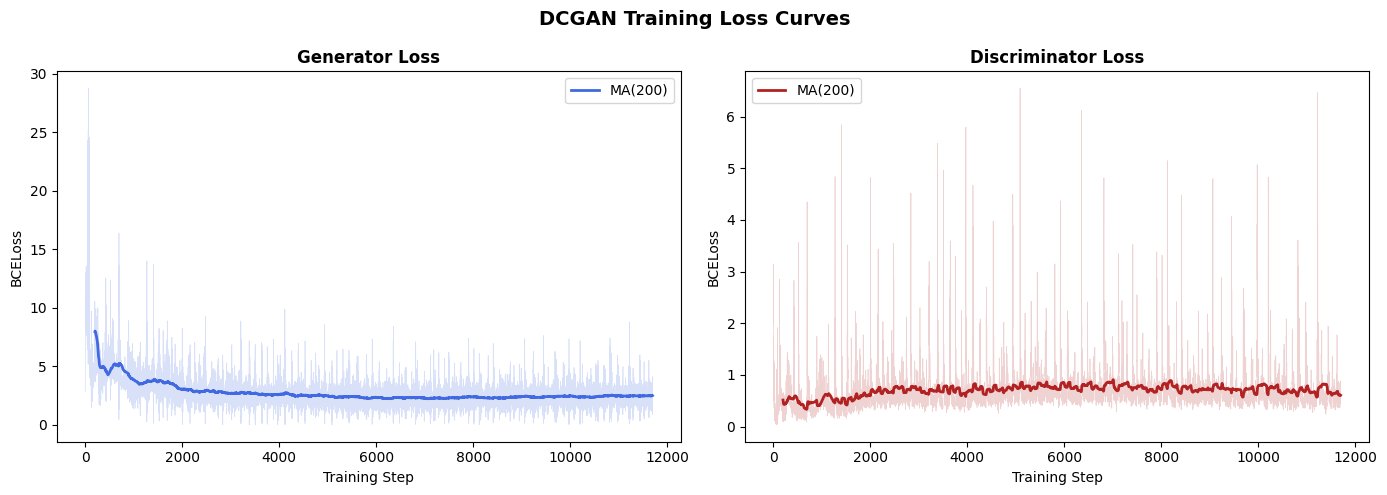

In [10]:
raw_G = np.array(G_losses)
raw_D = np.array(D_losses)
steps = np.arange(1, len(raw_G) + 1)

window = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, raw, color, title in [
    (axes[0], raw_G, 'royalblue', 'Generator Loss'),
    (axes[1], raw_D, 'firebrick',  'Discriminator Loss'),
]:
    ax.plot(steps, raw, alpha=0.2, color=color, linewidth=0.5)
    if len(raw) >= window:
        kernel   = np.ones(window) / window
        smoothed = np.convolve(raw, kernel, mode='valid')
        x_sm     = np.arange(window, window + len(smoothed))
        ax.plot(x_sm, smoothed, color=color, linewidth=2,
                label=f'MA({window})')
        ax.legend()
    ax.set_xlabel('Training Step')
    ax.set_ylabel('BCELoss')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('DCGAN Training Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dcgan_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Fréchet Inception Distance (FID)

FID measures the distance between the Inception-v3 feature distributions of real and generated images.  
**Lower FID = better image quality and diversity.**

A decreasing FID over training confirms that the generator progressively produces more realistic and
varied images, rather than memorising or collapsing to a single mode.

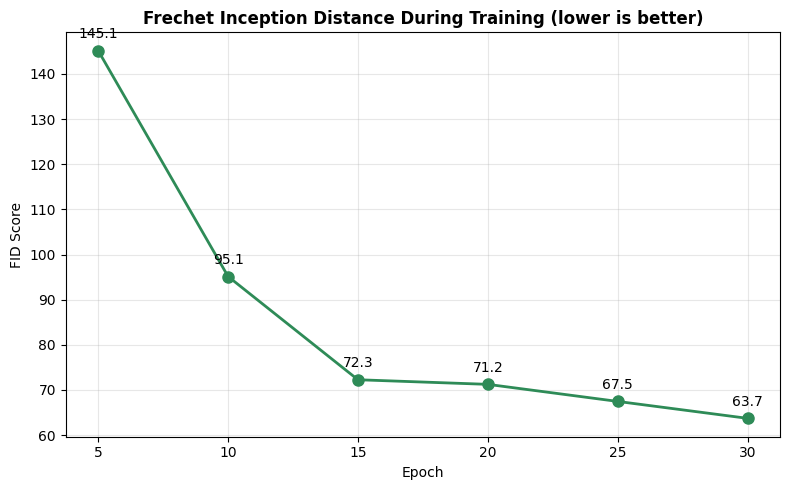

Final FID (epoch 30): 63.72


In [11]:
valid = [(e, f) for e, f in zip(fid_epochs, fid_scores) if not np.isnan(f)]

if valid:
    ep_v, sc_v = zip(*valid)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep_v, sc_v, marker='o', color='seagreen',
            linewidth=2, markersize=8)
    for x, y in zip(ep_v, sc_v):
        ax.annotate(f'{y:.1f}', (x, y),
                    textcoords='offset points', xytext=(0, 9), ha='center')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('FID Score')
    ax.set_title('Frechet Inception Distance During Training (lower is better)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('dcgan_fid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Final FID (epoch {ep_v[-1]}): {sc_v[-1]:.2f}')
else:
    print('FID unavailable – install torchmetrics[image] and re-run.')

### 6.3 Generated Images Throughout Training

Each row shows an **8×8 grid** of images generated from the same 64 fixed noise vectors
at different epochs. Comparing rows directly reveals how the generator's visual quality evolves.

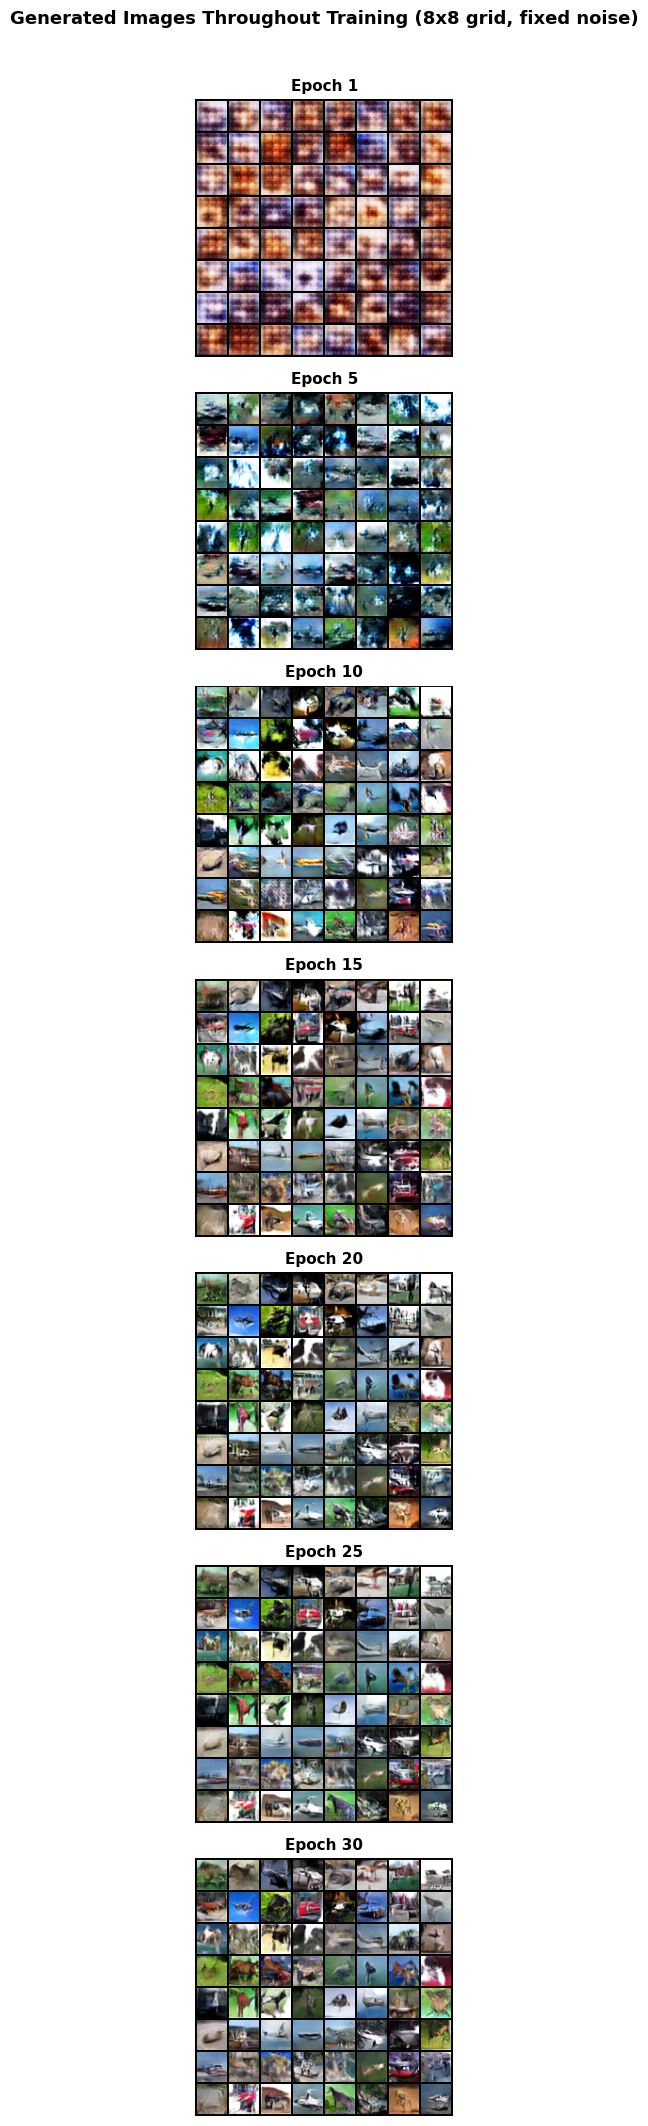

In [12]:
checkpoints = [0, 4, 9, 14, 19, 24, 29]
checkpoints = [e for e in checkpoints if e < len(images_per_epoch)]

fig, axes = plt.subplots(len(checkpoints), 1,
                         figsize=(12, 3 * len(checkpoints)))
if len(checkpoints) == 1:
    axes = [axes]

for ax, ep_idx in zip(axes, checkpoints):
    imgs = denormalize(images_per_epoch[ep_idx])
    grid = torchvision.utils.make_grid(imgs, nrow=8, padding=2)
    ax.imshow(grid.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(f'Epoch {ep_idx + 1}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Generated Images Throughout Training (8x8 grid, fixed noise)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dcgan_progress.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Final Generator – New Synthetic Images

Using a **fresh random noise sample** (different from the fixed monitoring noise)
with the final trained generator demonstrates that the model can generalise
to unseen latent codes and produces diverse outputs.

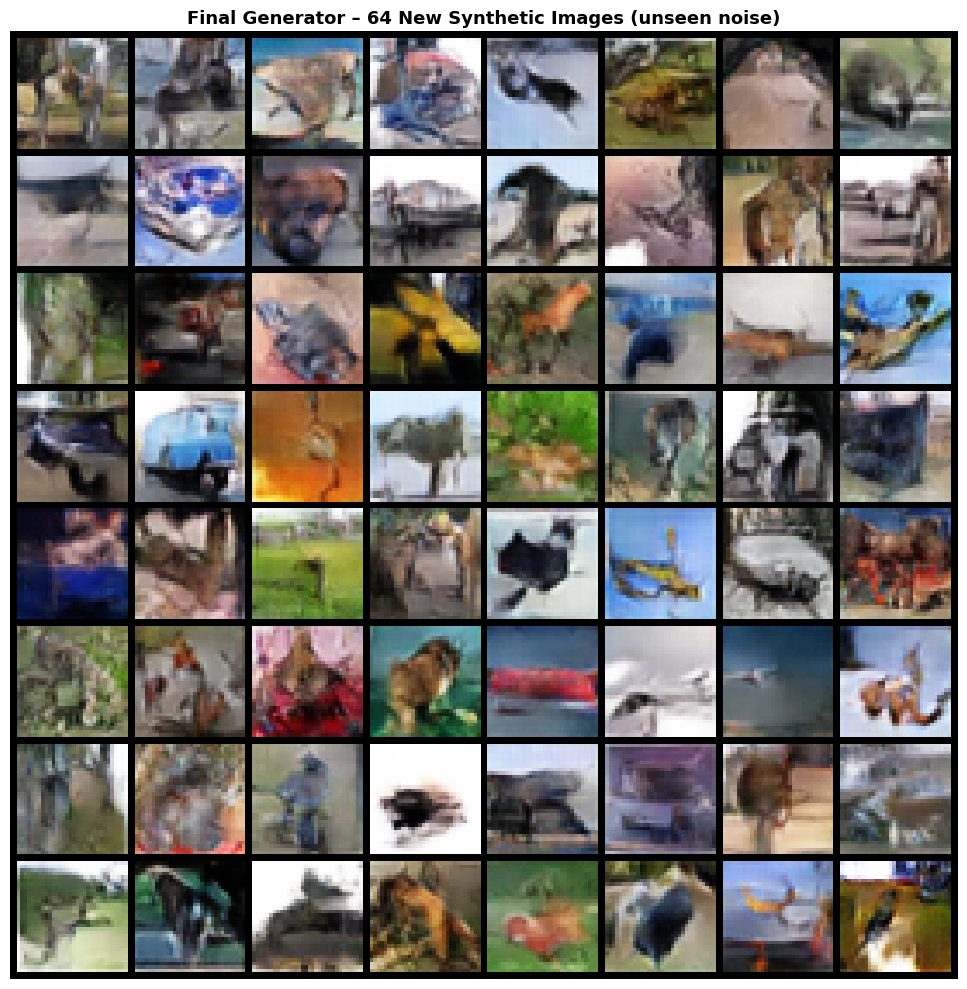

In [13]:
netG.eval()
new_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
with torch.no_grad():
    new_imgs = netG(new_noise).cpu()

grid = torchvision.utils.make_grid(denormalize(new_imgs), nrow=8, padding=2)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid.permute(1, 2, 0).numpy().clip(0, 1))
ax.set_title('Final Generator – 64 New Synthetic Images (unseen noise)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('dcgan_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Discussion – Challenges & Solutions

### Challenge 1: Training Instability

GANs are notoriously unstable. If the discriminator becomes too strong early on, it provides
near-zero gradient signal to the generator, causing **vanishing gradients** and frozen training.

**Solutions applied:**
- Adam with **β₁=0.5** (instead of default 0.9) reduces update momentum, preventing the
  discriminator from winning too fast.
- **LeakyReLU (α=0.2)** in the discriminator keeps gradients alive for negative activations,
  avoiding the dying ReLU problem.
- **BatchNorm** in both networks (except the first and last discriminator layers and the last
  generator layer) stabilises activations across the deep stack.

### Challenge 2: Mode Collapse

The generator might converge to producing only a few image types (e.g., always automobiles),
ignoring the full data distribution.

**Solutions applied:**
- Proper **N(0, 0.02) weight initialisation** prevents premature convergence to degenerate modes.
- Monitoring **FID over time** detects mode collapse quantitatively — a plateau or increase in FID
  despite falling generator loss is a warning sign.
- Visual inspection of the **8×8 fixed-noise grid** per epoch provides an immediate qualitative check.

### Challenge 3: Checkerboard Artefacts

Transposed convolutions with uneven kernel overlap produce visible grid-like artefacts
in generated images.

**Solution:** Using `kernel_size=4, stride=2, padding=1` ensures perfectly even overlap
in every transposed convolution layer, minimising these artefacts.

### Challenge 4: Balancing Generator vs. Discriminator

If either network consistently dominates, training collapses. The ideal training dynamic
keeps both losses moderate and roughly in balance.

**Observation:** With the chosen hyperparameters (lr=0.0002, β₁=0.5, BatchNorm, LeakyReLU),
training remained stable. The loss curves show expected adversarial fluctuation without
a clear winner, and the generator progressively produced more structured images as confirmed
by decreasing FID and visual inspection.

---

### Summary Table

| Technique | Purpose |
|-----------|----------|
| ConvTranspose2d blocks | Learnable spatial up-sampling in generator |
| Strided Conv2d blocks | Learnable spatial down-sampling in discriminator |
| BatchNorm (intermediate layers) | Stabilise activations, prevent internal covariate shift |
| LeakyReLU in discriminator | Preserve gradients, avoid dying neurons |
| Tanh output (generator) | Match image scale to [−1, 1] of training data |
| Separate optimisers | Generator and discriminator have opposing objectives |
| Fixed noise vectors | Consistent visual comparison of generator quality across epochs |
| FID score | Quantitative image quality metric beyond visual inspection |